In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [12]:
image = cv2.imread("img2.jpg", cv2.IMREAD_GRAYSCALE)


if image is None:
    print(f"Error: Could not load image '{image_path}'. Please ensure the file exists.")

In [ ]:

height, width = image.shape # Correctly get dimensions from a NumPy array
total_pixels = height * width

# 2. Initialize histogram array
hist = np.zeros(256, dtype=int)


for row in range(height):
    for col in range(width):
        intensity = image[row, col]
        hist[intensity] += 1

In [20]:
# 4. Normalize (PDF)
pdf = hist / total_pixels
pdf

array([2.30501739e-03, 3.97416791e-04, 5.76254347e-04, 6.75608544e-04,
       7.35221063e-04, 1.21212121e-03, 1.03328366e-03, 1.25186289e-03,
       1.35121709e-03, 2.10630899e-03, 2.38450075e-03, 2.48385494e-03,
       2.84153005e-03, 2.76204670e-03, 3.49726776e-03, 3.47739692e-03,
       4.23248882e-03, 5.26577248e-03, 5.20615996e-03, 6.19970194e-03,
       6.08047690e-03, 7.33233979e-03, 8.26626925e-03, 8.14704421e-03,
       7.72975658e-03, 7.59066071e-03, 8.64381520e-03, 7.90859414e-03,
       8.30601093e-03, 7.45156483e-03, 7.70988574e-03, 8.14704421e-03,
       8.20665673e-03, 8.20665673e-03, 8.30601093e-03, 9.47839046e-03,
       9.27968207e-03, 9.83606557e-03, 9.73671138e-03, 1.24788872e-02,
       1.18430204e-02, 1.09687034e-02, 1.06110283e-02, 1.13661202e-02,
       7.47143567e-03, 7.41182315e-03, 6.61698957e-03, 6.85543964e-03,
       6.27918530e-03, 5.52409339e-03, 5.48435171e-03, 4.78887233e-03,
       4.62990561e-03, 4.59016393e-03, 4.78887233e-03, 4.27223050e-03,
      

In [22]:
cdf = np.zeros(256, dtype=float)
running_sum = 0



for i in range(256):
    running_sum += pdf[i]
    cdf[i] = running_sum

In [14]:
# We use round() as per your pseudocode to get valid integer pixel values
new_value = np.zeros(256, dtype=np.uint8)
for i in range(256):
    new_value[i] = round(255 * cdf[i])

In [15]:
# We create a copy to keep the original intact
equalized_img = np.zeros_like(image)
for r in range(height):
    for c in range(width):
        p = image[r, c]
        equalized_img[r, c] = new_value[p]

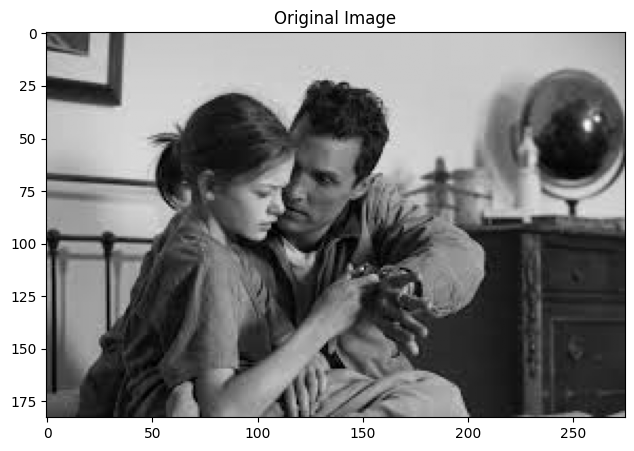

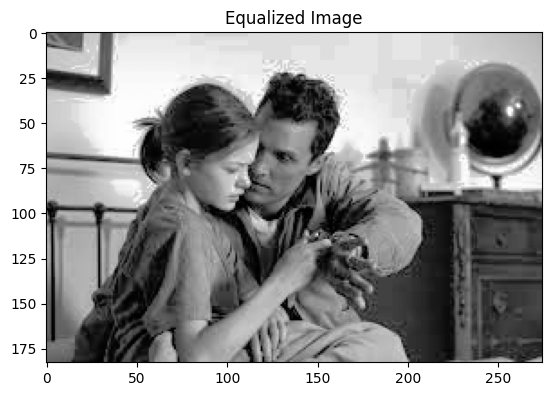

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.show()


plt.imshow(equalized_img, cmap='gray')
plt.title('Equalized Image')
plt.show()